<a href="https://colab.research.google.com/github/edik06031-rgb/DTA_2026/blob/main/HW/practice_stat_tests_HARDER_19_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("/content/drive/MyDrive/DataAnalitic/saas_users.csv")
ab = pd.read_csv("/content/drive/MyDrive/DataAnalitic/onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [26]:
# Завдання 1:
print(users.describe().round(2))

mean_tickets = users['support_tickets'].mean()
median_tickets = users['support_tickets'].median()

print(f"\nСереднє support_tickets: {mean_tickets:.3f}")
print(f"Медіана support_tickets: {median_tickets:.3f}")

        user_id  support_tickets  weekly_sessions  nps_before  nps_after
count   1200.00          1200.00           1200.0     1200.00    1200.00
mean   10600.50             2.10             11.5        6.93       7.15
std      346.55             2.61              6.4        1.92       2.20
min    10001.00             0.00              1.0        1.00       0.00
25%    10300.75             0.00              7.0        6.00       6.00
50%    10600.50             1.00             11.0        7.00       7.00
75%    10900.25             3.00             16.0        8.00       9.00
max    11200.00            20.00             38.0       10.00      10.00

Середнє support_tickets: 2.105
Медіана support_tickets: 1.000


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Середнє значення support_tickets становить 2.10, тоді як медіана — лише 1.0. Середнє помітно більше за медіану, що є класичною ознакою скошеного праворуч (right-skewed) розподілу: більшість користувачів мають небагато звернень (0-1), але є невелика кількість користувачів із дуже великою кількістю звернень (максимум — 20), і саме ці викиди «тягнуть» середнє вгору.

Для такого стовпця варто бути обережним із t-тестом, бо t-тест порівнює саме СЕРЕДНІ значення, а середнє в скошеному розподілі з викидами не дуже добре репрезентує «типового» користувача. Кілька користувачів з 15-20 зверненнями можуть суттєво змістити середнє групи і вплинути на результат тесту, навіть якщо у переважної більшості користувачів ситуація типова (0-2 звернення). Тому варто або перевіряти результат на робастність (наприклад, порівнюючи медіани чи використовуючи непараметричні тести), або уважно дивитись на викиди перед застосуванням t-тесту.*

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

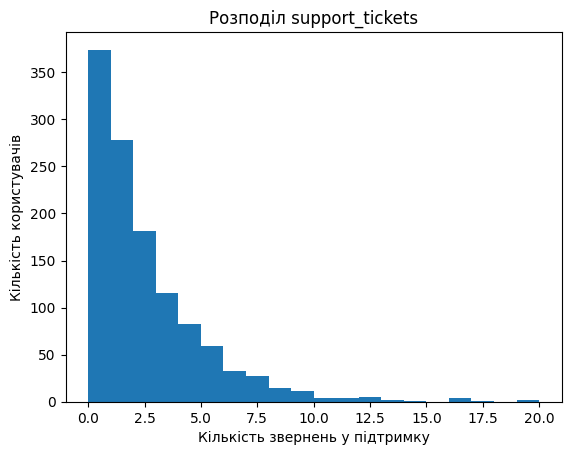

In [27]:
# Завдання 2:
users['support_tickets'].plot(kind='hist', bins=20)
plt.xlabel('Кількість звернень у підтримку')
plt.ylabel('Кількість користувачів')
plt.title('Розподіл support_tickets')
plt.show()

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Гістограма підтверджує висновок із попереднього завдання: розподіл скошений праворуч. Більшість користувачів зосереджені в лівій частині графіка (0-3 звернення), стовпчики там найвищі, а далі гістограма утворює довгий «хвіст», що тягнеться у бік великих значень (10+ звернень), де стовпчики дуже низькі — таких користувачів мало, але вони є.

Це типовий скошений (skewed) розподіл, де середнє і медіана не збігаються саме через цей хвіст із рідкісними, але «важкими» значеннями. Гістограма наочно показує те, про що ми здогадались із чисел: розподіл далекий від симетричного, тож варто враховувати це при подальшому статистичному аналізі цього стовпця.*

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [28]:
# Завдання 3:
print('Середня weekly_sessions по тарифах:')
print(users.groupby('plan')['weekly_sessions'].mean().round(2))

groups = [users[users.plan == p]['weekly_sessions'] for p in users['plan'].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4e}')

Середня weekly_sessions по тарифах:
plan
Business    19.59
Free         7.93
Pro         13.30
Name: weekly_sessions, dtype: float64

F-статистика: 415.1936
p-значення: 1.0908e-137


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Середня кількість сеансів на тиждень помітно різниться між тарифами: Business — 19.59, Pro — 13.30, Free — 7.93. ANOVA дала F = 415.19, p ≈ 1.09×10⁻¹³⁷ (набагато менше 0.05).

Ми відхиляємо нульову гіпотезу: тарифи статистично значуще відрізняються за активністю користувачів. Найактивніший тариф — Business.

Проте за результатом ANOVA ми НЕ можемо одразу стверджувати, що, наприклад, саме Pro значущо активніший за Free — ANOVA лише каже, що ХОЧА Б ОДНА пара груп з трьох відрізняється, але не вказує, яка саме. Можливо, відмінність тримається лише на парі Business vs Free, а Pro і Free насправді статистично не відрізняються між собою. Щоб перевірити конкретні пари, потрібні додаткові попарні (post-hoc) тести.*

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [29]:
# Завдання 4:
print('Середня weekly_sessions по регіонах:')
print(users.groupby('region')['weekly_sessions'].mean().round(2))

groups = [users[users.region == r]['weekly_sessions'] for r in users['region'].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середня weekly_sessions по регіонах:
region
Americas    10.78
Asia        11.52
Europe      12.28
Name: weekly_sessions, dtype: float64

F-статистика: 5.5455
p-значення: 0.0040


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Середня активність по регіонах: Europe — 12.28, Asia — 11.52, Americas — 10.78 сеансів на тиждень. ANOVA дала F = 5.55, p = 0.004 — також статистично значуще (p < 0.05), хоча й не настільки екстремально мале, як для тарифів.

Якщо порівняти обидва результати: різниця між тарифами набагато сильніша і за величиною (від 7.93 до 19.59 — майже втричі), і за статистичною «впевненістю» (p ≈ 10⁻¹³⁷ проти p = 0.004), тоді як різниця між регіонами невелика за абсолютною величиною (від 10.78 до 12.28 — приблизно на 1.5 сеансу) і статистично значуща, але набагато слабше виражена.

Для продукту це означає, що тариф — набагато сильніший фактор, повʼязаний з активністю користувача, ніж регіон. Тобто якщо потрібно прогнозувати чи впливати на активність користувачів, фокусуватись на типі підписки набагато доцільніше, ніж на географії — регіональні відмінності є, але вони незначні порівняно з різницею між тарифами.*

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [30]:
# Завдання 5:
mean_before = users['nps_before'].mean()
mean_after = users['nps_after'].mean()
mean_change = (users['nps_after'] - users['nps_before']).mean()

t_stat, p_value = stats.ttest_rel(users['nps_after'], users['nps_before'])

print(f'Середній NPS ДО: {mean_before:.3f}')
print(f'Середній NPS ПІСЛЯ: {mean_after:.3f}')
print(f'Середня зміна (after - before): {mean_change:.4f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4e}')

Середній NPS ДО: 6.930
Середній NPS ПІСЛЯ: 7.149
Середня зміна (after - before): 0.2192
t-статистика: 5.4992
p-значення: 4.6597e-08


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Парний t-тест показав p ≈ 4.66×10⁻⁸ — це набагато менше 0.05, тож зміна NPS статистично значуща: ми відхиляємо нульову гіпотезу про відсутність змін.

Однак сама величина зміни — лише +0.22 бала за шкалою від 0 до 10 (з 6.93 до 7.15). Це дуже маленький практичний приріст.

Тут і проявляється пастка з вступу до розділу: статистична значущість каже лише, що зміна НЕ випадкова (вона стабільно повторюється на великій кількості користувачів — 1200), але не каже, що ця зміна ВАЖЛИВА для бізнесу. Збалансований висновок: оновлення онбордингу дало статистично достовірне, але дуже скромне покращення лояльності клієнтів — приріст на 0.2 бала навряд чи відчутно змінить поведінку клієнтів (наприклад, ймовірність продовжити підписку) і не варто презентувати це керівництву як «значний прорив», навіть попри формально значущий p.*

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [31]:
# Завдання 6:
conversion = ab.groupby('variant')['signed_up'].mean()
print('Конверсія по варіантах:')
print(conversion.round(5))

diff_pp = (conversion['Treatment'] - conversion['Control']) * 100
print(f'\nРізниця (Treatment - Control): {diff_pp:.3f} відсоткових пунктів')

Конверсія по варіантах:
variant
Control      0.19876
Treatment    0.20764
Name: signed_up, dtype: float64

Різниця (Treatment - Control): 0.888 відсоткових пунктів


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Конверсія в Control становить 19.88%, у Treatment — 20.76%, тобто різниця складає приблизно 0.89 відсоткового пункту.

На перший погляд це дуже мала різниця — менше одного відсоткового пункту. Якщо дивитись лише на ці числа, не проводячи тест, можна було б подумати, що це несуттєве коливання, яке цілком могло виникнути випадково.*

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [32]:
# Завдання 7:
ct_ab = pd.crosstab(ab['variant'], ab['signed_up'])
print('Таблиця спряженості (variant x signed_up):')
print(ct_ab)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_ab)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.6f}')
print(f'степені свободи: {dof}')


Таблиця спряженості (variant x signed_up):
signed_up      0      1
variant                
Control    40062   9938
Treatment  39618  10382

chi2-статистика: 12.1209
p-значення: 0.000499
степені свободи: 1


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**
*Тест хі-квадрат дав chi2 = 12.12, p ≈ 0.0005 — це значно менше 0.05, тож різниця між Control і Treatment є статистично значущою.

Парадокс пояснюється розміром вибірки: тест на 100 000 користувачів (по 50 000 у кожній групі) має величезну статистичну потужність — він здатний «відчути» навіть дуже маленьку, майже непомітну різницю в пропорціях і впевнено відрізнити її від нуля. При такому обсязі даних випадкові коливання вибірки стають дуже малими, тому навіть різниця в 0.89 відсоткового пункту вже виходить за межі того, що можна пояснити випадковістю.

Тут важливо розрізняти два різні питання: «чи різниця ВЗАГАЛІ є (не нульова)?» — на це тест відповідає «так, статистично значуще», і «чи різниця ВЕЛИКА і важлива?» — а на це p-значення відповіді не дає. Великий обсяг вибірки робить тест чутливим до виявлення навіть мікроскопічних, практично неважливих відмінностей.*

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Рішення тут не очевидне і вимагає зважування вигоди та витрат, а не лише погляду на p-значення.

З одного боку, приріст конверсії статистично підтверджений і не є випадковістю — тобто Treatment дійсно трохи краще, а не просто «здається» кращим. При величезному масштабі бізнесу (мільйони користувачів на рік) навіть 0.89 в.п. може у абсолютних числах означати помітну кількість додаткових реєстрацій, і тоді інвестиція може окупитись.

З іншого боку, якщо впровадження нового онбордингу справді дороге (переписання коду, навчання команди, ризики при релізі), а приріст конверсії дуже малий у відносному вираженні (з 19.88% до 20.76% — приріст менш ніж на 5% відносно бази), варто порахувати очікувану фінансову вигоду від додаткових реєстрацій і порівняти її з вартістю впровадження та супроводу. Якщо очікуваний прибуток від приросту конверсії перевищує витрати на розробку й підтримку — впроваджувати варто; якщо ні (наприклад, у компанії з невеликим трафіком, де абсолютний приріст у користувачах буде малим) — можливо, варто почекати, протестувати дешевші покращення або зосередитись на інших напрямках з більшим потенційним ефектом. Моя рекомендація: розрахувати ROI на основі очікуваного обсягу трафіку та вартості розробки, а не приймати рішення лише на основі статистичної значущості.*

---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [33]:
# Завдання 8:
ct_plan_feature = pd.crosstab(users['plan'], users['feature_adopted'])
print('Таблиця спряженості (plan x feature_adopted):')
print(ct_plan_feature)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_plan_feature)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4e}')
print(f'степені свободи: {dof}')

print('\nЧастка "Так" по тарифах:')
print(pd.crosstab(users['plan'], users['feature_adopted'], normalize='index').round(3))

Таблиця спряженості (plan x feature_adopted):
feature_adopted   Ні  Так
plan                     
Business          54  115
Free             453  147
Pro              204  227

chi2-статистика: 143.1339
p-значення: 8.2961e-32
степені свободи: 2

Частка "Так" по тарифах:
feature_adopted     Ні    Так
plan                         
Business         0.320  0.680
Free             0.755  0.245
Pro              0.473  0.527


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Тест хі-квадрат дав chi2 = 143.13, p ≈ 8.3×10⁻³² — статистично значущий звʼязок між тарифом і прийняттям нової функції.

Частка користувачів, які прийняли функцію: Business — 68.0%, Pro — 52.7%, Free — 24.5%. Чим дорожчий тариф, тим частіше користувачі застосовують нову функцію — Business-користувачі приймають її майже втричі частіше, ніж користувачі Free.

Для продуктової стратегії це означає, що нова функція особливо резонує з платними, заангажованими користувачами. Це може свідчити про те, що функція орієнтована на потреби «просунутих» користувачів, або що Business-користувачі взагалі активніші й більш відкриті до нових можливостей продукту. Команді варто або підвищити видимість/просування цієї функції серед Free-користувачів (можливо, через освітній контент чи онбординг), або, навпаки, розглянути функцію як додатковий аргумент для апсейлу на дорожчі тарифи.*

#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [34]:
# Завдання 9:
ct_source_feature = pd.crosstab(users['signup_source'], users['feature_adopted'])
print('Таблиця спряженості (signup_source x feature_adopted):')
print(ct_source_feature)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_source_feature)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4f}')
print(f'степені свободи: {dof}')

print('\nЧастка "Так" по джерелах реєстрації:')
print(pd.crosstab(users['signup_source'], users['feature_adopted'], normalize='index').round(3))

Таблиця спряженості (signup_source x feature_adopted):
feature_adopted   Ні  Так
signup_source            
Ads              208  128
Referral         177  100
Search           227  186
Social            99   75

chi2-статистика: 7.0022
p-значення: 0.0718
степені свободи: 3

Частка "Так" по джерелах реєстрації:
feature_adopted     Ні    Так
signup_source                
Ads              0.619  0.381
Referral         0.639  0.361
Search           0.550  0.450
Social           0.569  0.431


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Тест хі-квадрат дав chi2 = 7.00, p = 0.0718 — це трохи більше за умовний порог 0.05, тобто результат «на межі».

Коректно НЕ казати «майже значущо, тож зв'язок, ймовірно, є» — порогове значення 0.05 є умовністю, а не точкою, після якої «правда» раптом стає «неправдою». p = 0.07 означає, що за обраного рівня довіри (α = 0.05) у нас НЕДОСТАТНЬО статистичних доказів, щоб відхилити нульову гіпотезу про відсутність зв'язку — але це не те саме, що довести, що зв'язку точно немає.

Перед тим, як робити остаточний висновок, я б порадив(ла): (1) не оголошувати зв'язок між джерелом реєстрації і прийняттям функції встановленим фактом; (2) якщо можливо, зібрати більше даних (поточна вибірка — 1200 користувачів, з 4 категоріями джерела розподіл частот не дуже великий), щоб тест мав більше статистичної потужності й дав чіткішу відповідь; (3) поставитися до результату обережно і трактувати його як «слабкий, непереконливий натяк на можливий звʼязок», а не як підставу для прийняття бізнес-рішень.*

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [35]:
# Завдання 10:
r, p_value = stats.pearsonr(users['support_tickets'], users['weekly_sessions'])
print(f'Коефіцієнт кореляції r: {r:.4f}')
print(f'p-значення: {p_value:.4f}')

Коефіцієнт кореляції r: 0.0290
p-значення: 0.3160


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Кореляція між кількістю звернень у підтримку та кількістю сеансів на тиждень: r = 0.029, p = 0.316.

Коефіцієнт r дуже близький до нуля, а p-значення значно більше 0.05 — отже, статистично значущого лінійного зв'язку між цими двома показниками не виявлено взагалі. Звернення у підтримку і кількість сеансів практично не повʼязані між собою в цих даних.

Міркування колеги хибне з двох причин. По-перше, в наших даних навіть базова умова — наявність значущого зв'язку — НЕ виконується: r майже нульовий і статистично незначущий, тож говорити про якийсь зв'язок взагалі немає підстав. По-друге, навіть якби кореляція була значущою, вона показує лише, що дві величини змінюються узгоджено, але нічого не каже про причинно-наслідковий напрямок. Твердження «сеанси викликають проблеми» — це лише одна з можливих інтерпретацій; так само правдоподібно могло бути навпаки (проблеми призводять до менших/більших сеансів) або існував би третій фактор, що впливає на обидві змінні одночасно. Кореляція ніколи сама по собі не доводить причинність — а тут навіть кореляції немає.*

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [36]:
# Завдання 11:
users['is_business'] = np.where(users['plan'] == 'Business', 'Так', 'Ні')
print(users['is_business'].value_counts())

is_business
Ні     1031
Так     169
Name: count, dtype: int64


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [37]:
# Завдання 12:
business = users[users['is_business'] == 'Так']['weekly_sessions']
non_business = users[users['is_business'] == 'Ні']['weekly_sessions']

print(f'Середня weekly_sessions (Business): {business.mean():.2f}')
print(f'Середня weekly_sessions (решта): {non_business.mean():.2f}')

t_stat, p_value = stats.ttest_ind(business, non_business)
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4e}')

Середня weekly_sessions (Business): 19.59
Середня weekly_sessions (решта): 10.18
t-статистика: 20.6342
p-значення: 3.4972e-81


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Перший інсайт: Business-користувачі суттєво активніші за решту. Середня кількість сеансів на тиждень у Business — 19.59, у решти користувачів — 10.18, тобто майже вдвічі більше.

Двовибірковий t-тест підтвердив, що ця різниця статистично значуща (p ≈ 3.5×10⁻⁸¹, набагато менше 0.05). Мовою бізнесу: користувачі найдорожчого тарифу не просто платять більше — вони і користуються продуктом значно інтенсивніше, що логічно узгоджується з тим, що Business орієнтований на найбільш заангажованих/професійних користувачів.*

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [38]:
# Завдання 13:
ct_business_feature = pd.crosstab(users['is_business'], users['feature_adopted'])
print('Таблиця спряженості (is_business x feature_adopted):')
print(ct_business_feature)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_business_feature)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4e}')
print(f'степені свободи: {dof}')

print('\nЧастка "Так" по групах:')
print(pd.crosstab(users['is_business'], users['feature_adopted'], normalize='index').round(3))

Таблиця спряженості (is_business x feature_adopted):
feature_adopted   Ні  Так
is_business              
Ні               657  374
Так               54  115

chi2-статистика: 59.3975
p-значення: 1.2883e-14
степені свободи: 1

Частка "Так" по групах:
feature_adopted     Ні    Так
is_business                  
Ні               0.637  0.363
Так              0.320  0.680


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Другий інсайт: Business-користувачі значно частіше приймають нову функцію. Серед Business-користувачів частка тих, хто почав застосовувати функцію, становить 68.0%, тоді як серед решти — лише 36.3%.

Тест хі-квадрат підтвердив, що цей звʼязок статистично значущий (chi2 = 59.40, p ≈ 1.3×10⁻¹⁴). Тобто статус Business явно повʼязаний із вищою готовністю пробувати нові можливості продукту — майже вдвічі вищою порівняно з іншими користувачами.*

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*Підсумок кейсу: дані малюють чіткий портрет Business-користувача як найбільш заангажованого сегмента — він використовує продукт майже вдвічі інтенсивніше (19.6 проти 10.2 сеансів на тиждень) і майже вдвічі частіше приймає нові функції (68% проти 36%), ніж решта користувачів.

Обидва висновки статистично надійні: різниця в активності підтверджена двовибірковим t-тестом з надзвичайно малим p-значенням, а звʼязок із прийняттям функції — тестом хі-квадрат, також з дуже малим p. Розміри вибірок (169 Business-користувачів проти 1031 інших) достатні, щоб довіряти цим результатам.

Водночас варто бути обережним із причинно-наслідковими твердженнями: ці дані показують стійкий звʼязок (кореляцію поведінки з тарифом), але не доводять, що сам факт переходу на Business ЗМУШУЄ людину бути активнішою чи відкритішою до нових функцій. Цілком можливо, що причинність працює і в інший бік: спершу найактивніші та найбільш заангажовані користувачі обирають дорожчий тариф (самовибір), а не тариф робить їх такими. Для бізнес-рішень (наприклад, чи варто активно мотивувати активних Free/Pro-користувачів переходити на Business) це означає, що портрет описаний правильно, але механізм причинності потребує додаткового дослідження — наприклад, спостереження за тим, як змінюється поведінка тих самих користувачів ДО і ПІСЛЯ переходу на Business.*

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
